# Introduction

## Context & Motivation
Social media is woven into students’ daily routines. While it connects and informs, excessive use may affect **academic performance** and **mental health**. This notebook explores those relationships using a structured, transparent, and reproducible workflow.

## Objectives
- **Understand distributions** of key variables (demographic, behavioral, academic, mental health).
- **Quantify relationships** between social media usage and student outcomes.
- **Model two targets**:
  1) **Academic Performance/Impact** (classification: logistic regression)  
  2) **Mental Health Score** (regression: Linear Regression, Random Forest, Gradient Boosting, XGBoost)
- **Interpret drivers**: identify which factors are most associated with performance and health.

## Data
- Demographics: Gender, Country, Academic Level, Relationship Status  
- Behavior: Most Used Platform, Avg_Daily_Usage_Hours, Sleep_Hours_Per_Night, Conflicts_Over_Social_Media  
- Outcomes: Affects_Academic_Performance, Mental_Health_Score, Addicted_Score  
> Missing values and obvious data issues are cleaned before analysis.

## Methodology

### 1) Univariate Analysis (EDA)
- Inspect distributions and outliers for numeric features (histograms/KDEs, boxplots).
- Profile categorical features (counts/percentages, bar + pie where helpful).

### 2) Bivariate Analysis (EDA)
**Numerical ↔ Numerical**
- Scatter plots (optionally with linear regression lines).
- **Correlation Matrix** + heatmap.
- Correlation coefficients: **Pearson** (linear), **Spearman** (rank-based, robust to monotonic but non-linear trends).

**Numerical ↔ Categorical**
- Grouped visuals: box/violin + jitter for distribution contrasts.
- **Parametric test**: **ANOVA** (one-way) when assumptions hold.  
- **Nonparametric test**: **Kruskal–Wallis** when normality/variance assumptions are doubtful.  
- Where applicable, report effect sizes (e.g., η² for ANOVA; Hedges’ g for two-group contrasts).

**Categorical ↔ Categorical**
- Contingency tables and **Chi-Square test of independence**.  
- Effect size: **Cramér’s V** (bias-corrected), alongside expected counts.

### 3) Modeling

**Task A — Academic Performance Impact (Classification)**
- Algorithm: **Logistic Regression**.
- Purpose: estimate how demographics/behavioral factors relate to academic impact.
- Evaluation: Accuracy, Precision, Recall, F1, Confusion Matrix (and ROC-AUC if probabilities available).

**Task B — Mental Health Score (Regression)**
- Algorithms: **Linear Regression**, **Random Forest**, **Gradient Boosting**, **XGBoost**.
- Purpose: model relationships and compare linear vs. ensemble learners.
- Evaluation: **MSE**, **MAE**, **R²** with a side-by-side comparison.
- Interpretation: feature importances/coefficient inspection (and permutation importance where relevant).

## Assumptions, Caveats & Ethics
- Data is **observational**; results show **associations, not causation**.
- Self-reported measures can include bias/noise.
- Potential confounders may exist; interpret results with care.
- Analyses are aimed at **understanding & early insights**, not medical/clinical diagnosis.

## How to Read This Notebook
1. **Cleaning & EDA**: understand the data first (univariate → bivariate with statistical tests).  
2. **Modeling**: build, evaluate, and compare models for the two targets.  
3. **Insights**: summarize what factors are most linked with academic impact and mental health.

## Deliverables
- Clear visuals for distributions and relationships.
- Statistical evidence (correlations, ANOVA/Kruskal–Wallis, Chi-Square, Cramér’s V).
- Model comparison for both targets with interpretable takeaways.


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from scipy.stats import pearsonr, spearmanr, chi2_contingency
import scipy.stats as stats

import xgboost as xgb
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, confusion_matrix, 
    classification_report, mean_squared_error, r2_score
)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.filterwarnings('ignore')

/kaggle/input/social-media-addiction-vs-relationships/Students Social Media Addiction.csv


# Load data 

In [2]:
df = pd.read_csv("/kaggle/input/social-media-addiction-vs-relationships/Students Social Media Addiction.csv")

In [3]:
df.head()

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,1,19,Female,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,6,In Relationship,3,8
1,2,22,Male,Graduate,India,2.1,Twitter,No,7.5,8,Single,0,3
2,3,20,Female,Undergraduate,USA,6.0,TikTok,Yes,5.0,5,Complicated,4,9
3,4,18,Male,High School,UK,3.0,YouTube,No,7.0,7,Single,1,4
4,5,21,Male,Graduate,Canada,4.5,Facebook,Yes,6.0,6,In Relationship,2,7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           705 non-null    int64  
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
dtypes: fl

In [5]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score
count,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000,705.000000
mean,353.000000,20.659574,4.918723,6.868936,6.226950,2.849645,6.436879
std,203.660256,1.399217,1.257395,1.126848,1.105055,0.957968,1.587165
min,1.000000,18.000000,1.500000,3.800000,4.000000,0.000000,2.000000
25%,177.000000,19.000000,4.100000,6.000000,5.000000,2.000000,5.000000
50%,353.000000,21.000000,4.800000,6.900000,6.000000,3.000000,7.000000
75%,529.000000,22.000000,5.800000,7.700000,7.000000,4.000000,8.000000
max,705.000000,24.000000,8.500000,9.600000,9.000000,5.000000,9.000000


In [6]:
df.shape

(705, 13)

# Data Cleaning

Missing values exist : False

Student_ID                      0
Age                             0
Gender                          0
Academic_Level                  0
Country                         0
Avg_Daily_Usage_Hours           0
Most_Used_Platform              0
Affects_Academic_Performance    0
Sleep_Hours_Per_Night           0
Mental_Health_Score             0
Relationship_Status             0
Conflicts_Over_Social_Media     0
Addicted_Score                  0
dtype: int64

Student_ID                      0.0
Age                             0.0
Gender                          0.0
Academic_Level                  0.0
Country                         0.0
Avg_Daily_Usage_Hours           0.0
Most_Used_Platform              0.0
Affects_Academic_Performance    0.0
Sleep_Hours_Per_Night           0.0
Mental_Health_Score             0.0
Relationship_Status             0.0
Conflicts_Over_Social_Media     0.0
Addicted_Score                  0.0
dtype: float64



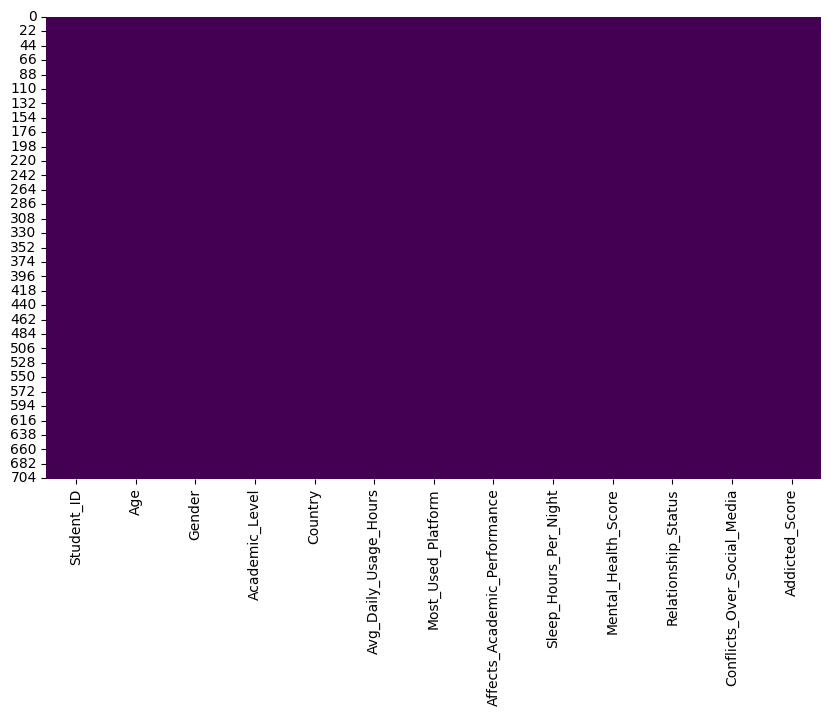

In [7]:
# Missing values

# check if any missing values exist
print(f"Missing values exist : {df.isnull().values.any()}")

# count NaN values in each column
missing_counts = df.isnull().sum()
print(f"\n{missing_counts}")

missing_percent = (df.isnull().sum() / len(df)) * 100
print(f"\n{missing_percent}\n")

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.show()

In [8]:
# Duplicates

# check if any duplicates exist 
print(df.duplicated().any())

# Count number of duplicate rows
print(f"\n{df.duplicated().sum()}")

# shows all rows that are duplicated
print(f"\n{df[df.duplicated()]}")

False

0

Empty DataFrame
Columns: [Student_ID, Age, Gender, Academic_Level, Country, Avg_Daily_Usage_Hours, Most_Used_Platform, Affects_Academic_Performance, Sleep_Hours_Per_Night, Mental_Health_Score, Relationship_Status, Conflicts_Over_Social_Media, Addicted_Score]
Index: []



Boxplots (Outliers check)



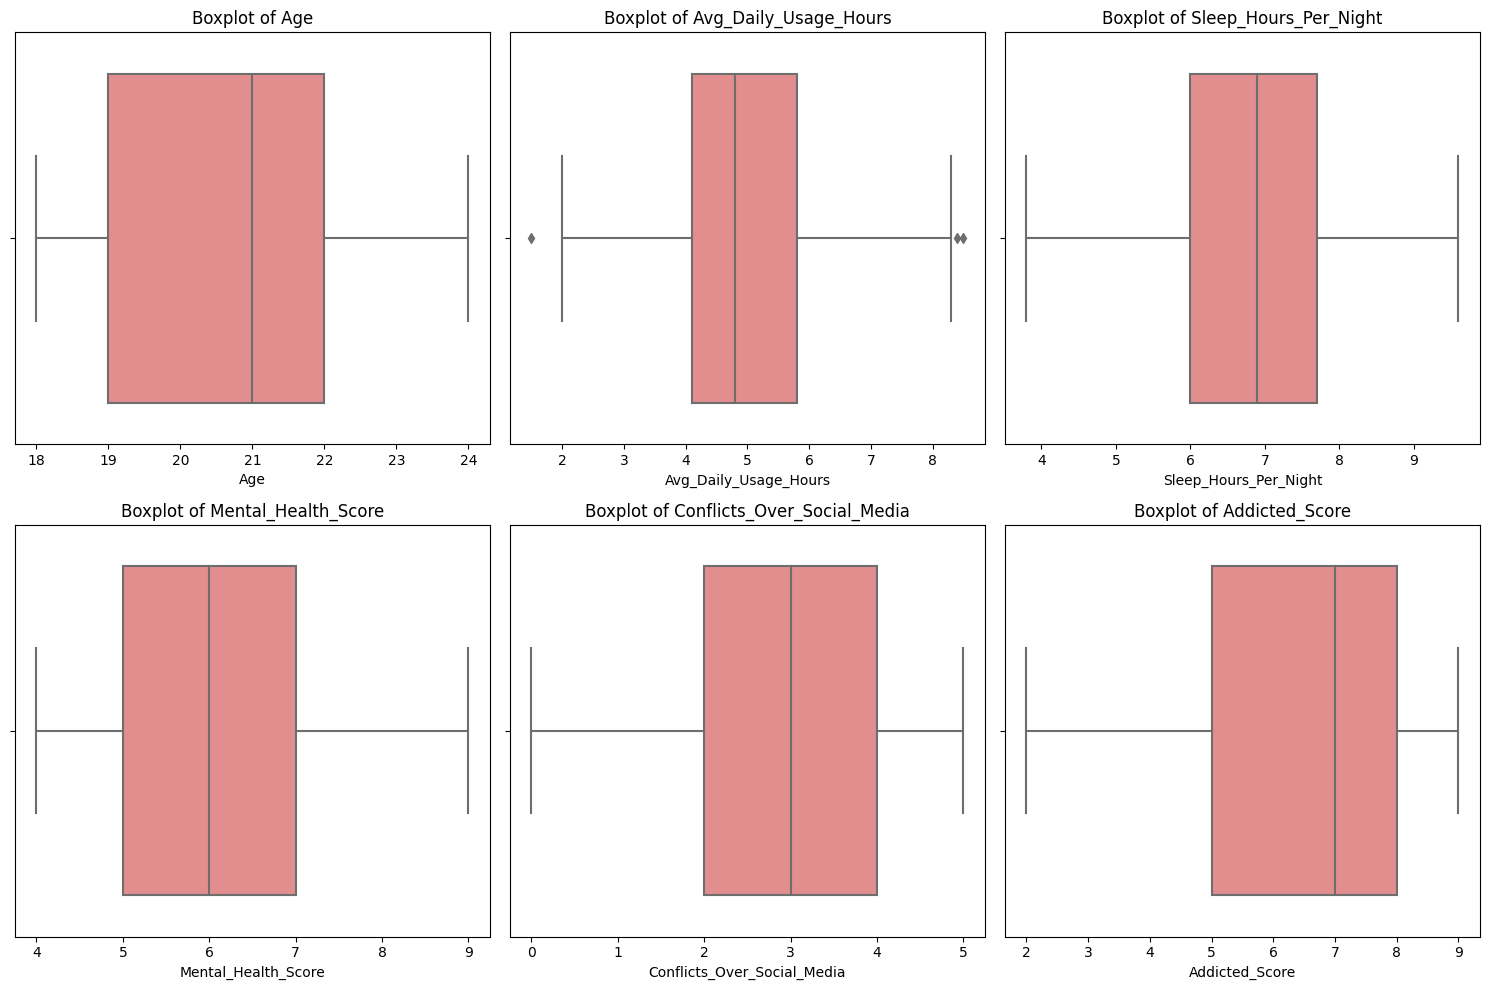

In [9]:
# Outliers

# Avg_Daily_Usage_Hours, Sleep_Hours_Per_Night, Mental_Health_Score, Addicted_Score

num_cols = ["Age", "Avg_Daily_Usage_Hours", "Sleep_Hours_Per_Night", 
            "Mental_Health_Score", "Conflicts_Over_Social_Media", "Addicted_Score"]

print("\nBoxplots (Outliers check)\n")
plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x=df[col], color="lightcoral")
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

# Univariate analysis (EDA)

## Numeric Features

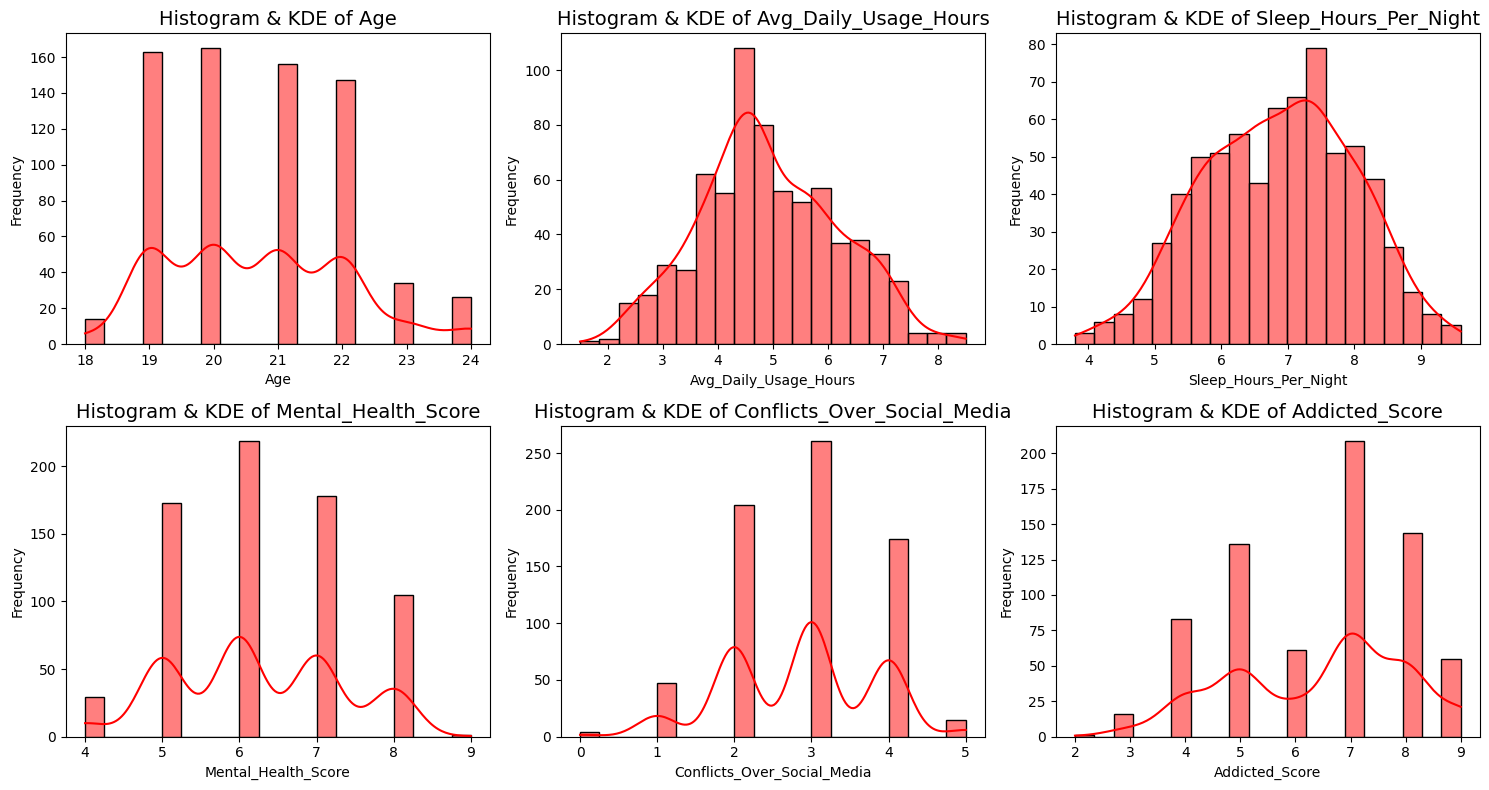

In [10]:
# Numeric features
numeric_cols = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Sleep_Hours_Per_Night",
    "Mental_Health_Score",
    "Conflicts_Over_Social_Media",
    "Addicted_Score"
]

n_rows = 2
n_cols = 3

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 8))


for i, col in enumerate(numeric_cols):
    row = i // n_cols  
    col_idx = i % n_cols 
    
    sns.histplot(df[col], kde=True, bins=20, color="red", edgecolor="black", ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f"Histogram & KDE of {col}", fontsize=14)
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## Categorical Features

In [11]:
# There is no country called Israel
df.loc[df['Country'] == 'Israel', 'Country'] = 'Palestine'

In [12]:
# checking unique values

categorical_cols = [
    "Gender", 
    "Academic_Level", 
    "Country", 
    "Most_Used_Platform", 
    "Affects_Academic_Performance", 
    "Relationship_Status"
]

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].unique())
    print(f"Count of unique value : {len(df[col].unique())}")
    print()


--- Gender ---
['Female' 'Male']
Count of unique value : 2

--- Academic_Level ---
['Undergraduate' 'Graduate' 'High School']
Count of unique value : 3

--- Country ---
['Bangladesh' 'India' 'USA' 'UK' 'Canada' 'Australia' 'Germany' 'Brazil'
 'Japan' 'South Korea' 'France' 'Spain' 'Italy' 'Mexico' 'Russia' 'China'
 'Sweden' 'Norway' 'Denmark' 'Netherlands' 'Belgium' 'Switzerland'
 'Austria' 'Portugal' 'Greece' 'Ireland' 'New Zealand' 'Singapore'
 'Malaysia' 'Thailand' 'Vietnam' 'Philippines' 'Indonesia' 'Taiwan'
 'Hong Kong' 'Turkey' 'Palestine' 'UAE' 'Egypt' 'Morocco' 'South Africa'
 'Nigeria' 'Kenya' 'Ghana' 'Argentina' 'Chile' 'Colombia' 'Peru'
 'Venezuela' 'Ecuador' 'Uruguay' 'Paraguay' 'Bolivia' 'Costa Rica'
 'Panama' 'Jamaica' 'Trinidad' 'Bahamas' 'Iceland' 'Finland' 'Poland'
 'Romania' 'Hungary' 'Czech Republic' 'Slovakia' 'Croatia' 'Serbia'
 'Slovenia' 'Bulgaria' 'Estonia' 'Latvia' 'Lithuania' 'Ukraine' 'Moldova'
 'Belarus' 'Kazakhstan' 'Uzbekistan' 'Kyrgyzstan' 'Tajikistan' 'A

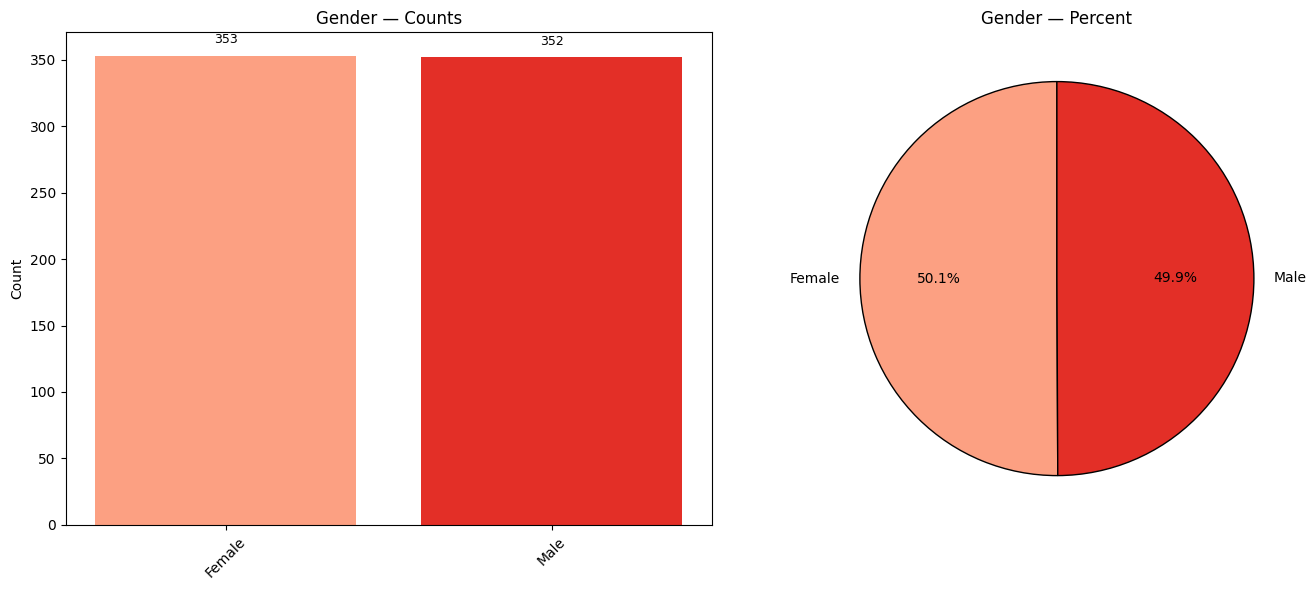

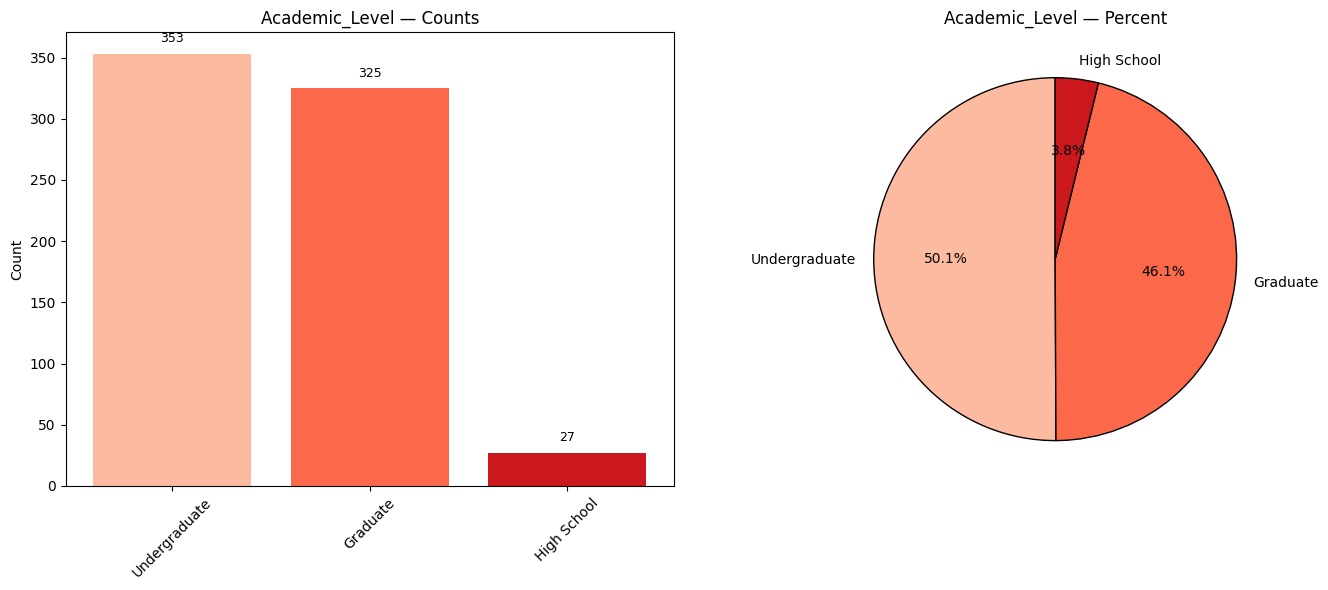

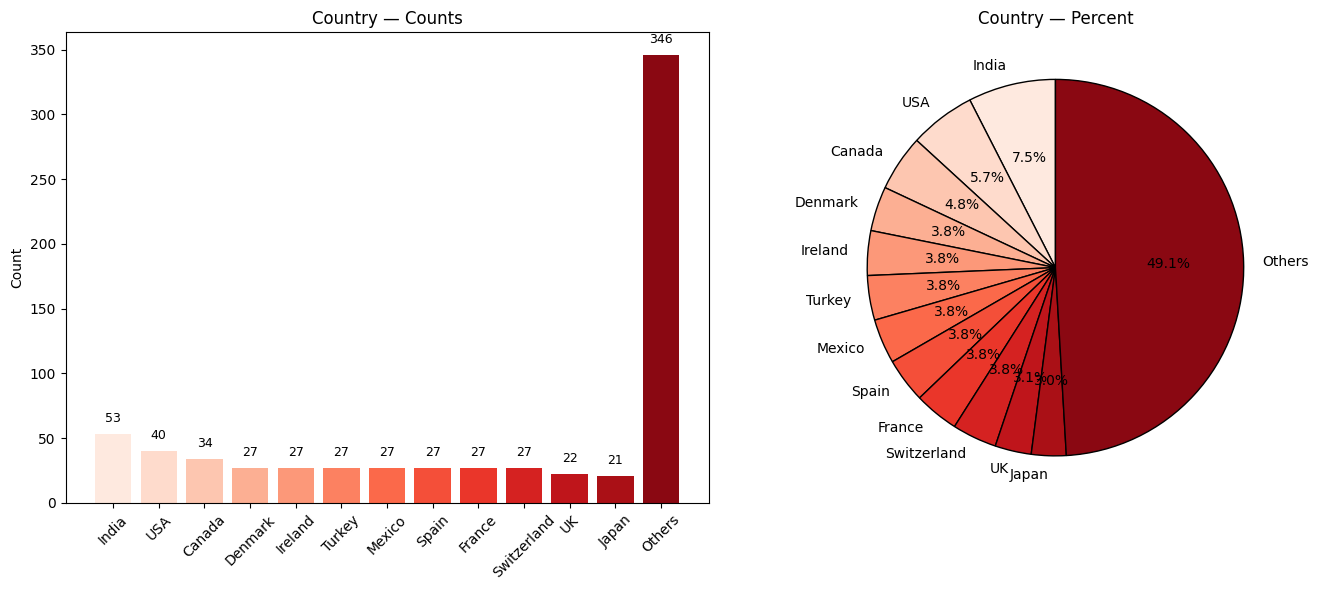

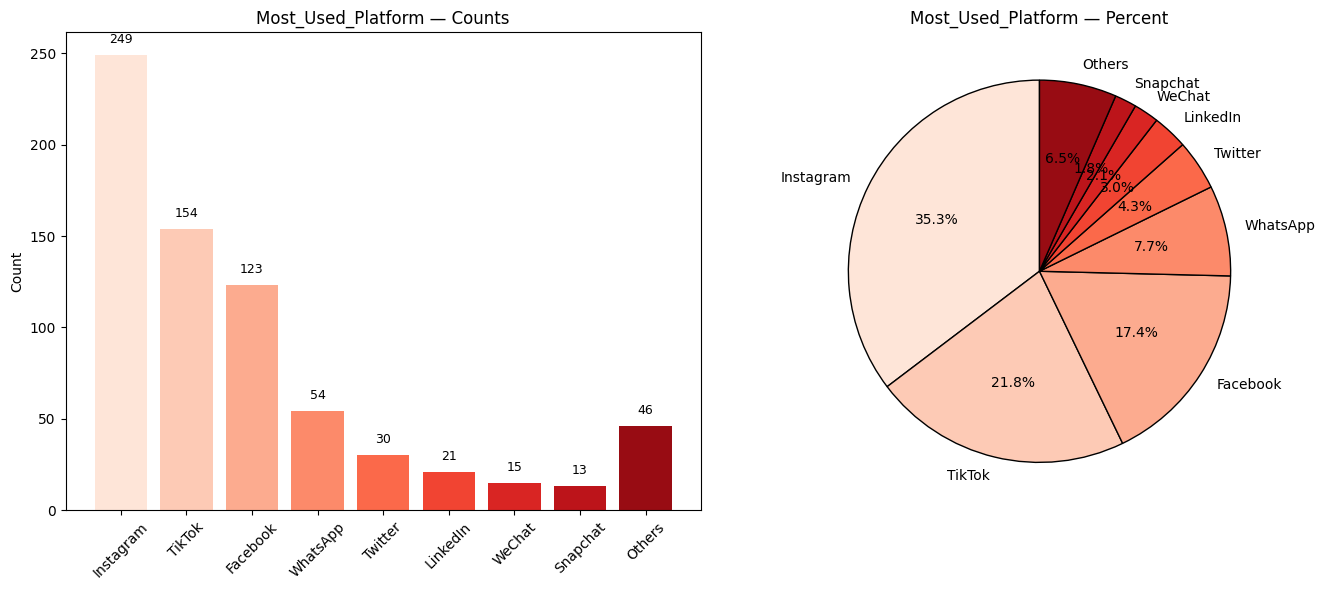

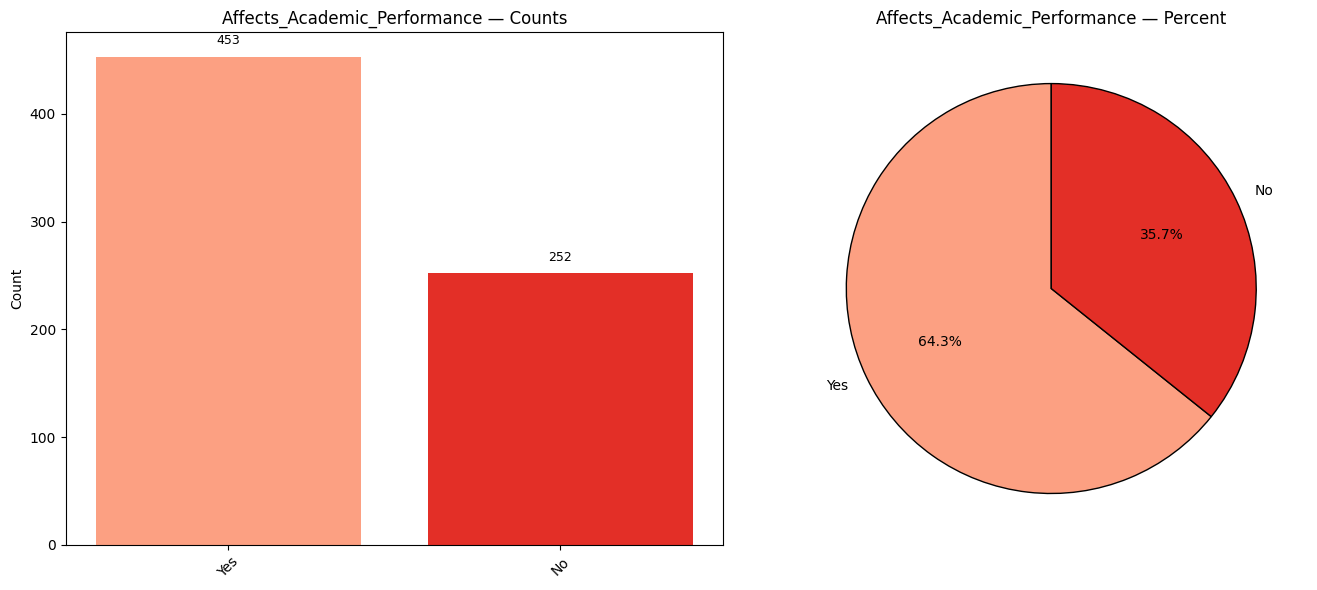

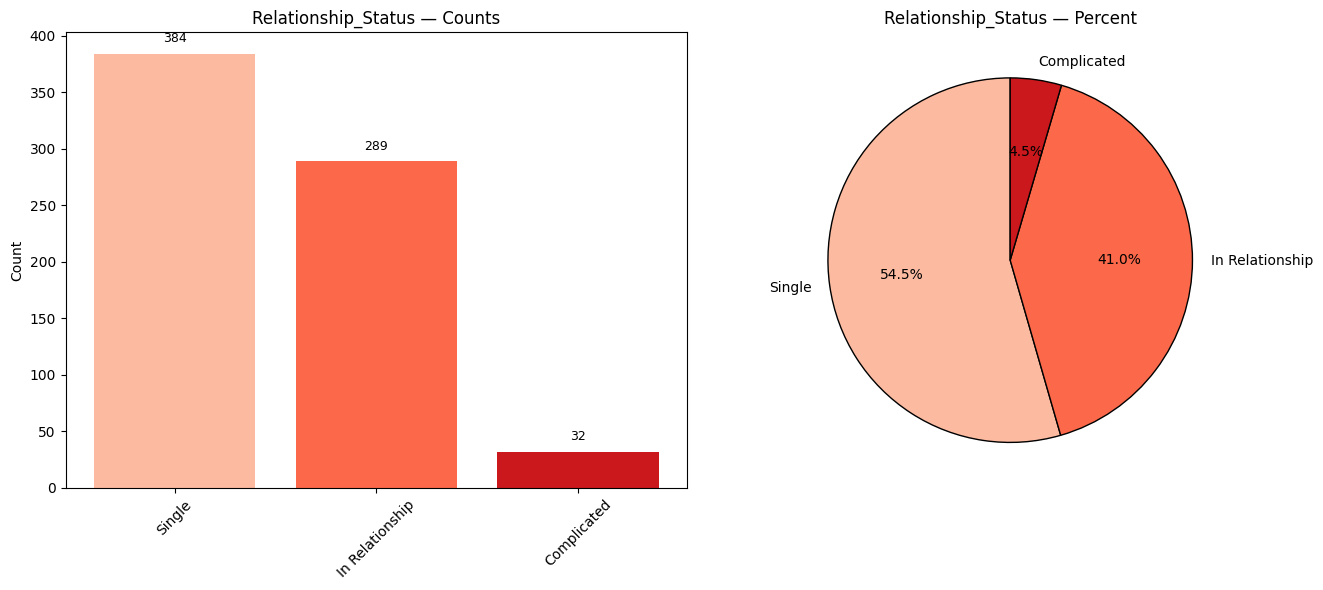

In [13]:
def plot_categorical_summary(df, col, top_n=10, min_freq=0):
    """
    Plot bar (counts) and pie (percent) for a categorical column.
    - Keeps top_n categories (after dropping NaNs). Others -> 'Others'.
    - Or, if min_freq > 0, anything below min_freq is grouped as 'Others'.
    """
    # Preprocess the data
    s = df[col].fillna("Missing").astype(str)
    vc = s.value_counts(dropna=False)

    # Group categories based on frequency threshold or top_n
    if min_freq > 0:
        major = vc[vc >= min_freq]
        others_count = vc[vc < min_freq].sum()
    else:
        major = vc.iloc[:top_n]
        others_count = vc.iloc[top_n:].sum()

    if others_count > 0:
        major["Others"] = others_count

    # Plot settings
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    colors = sns.color_palette("Reds", len(major))
    axes[0].bar(major.index, major.values, color=colors)
    axes[0].set_title(f"{col} — Counts")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis='x', rotation=45)

    for i, v in enumerate(major.values):
        axes[0].text(i, v + max(major.values)*0.02, str(int(v)), ha="center", va="bottom", fontsize=9)

    major.plot.pie(
        autopct="%1.1f%%",
        colors=colors,
        startangle=90,
        wedgeprops={"edgecolor": "black"},
        ax=axes[1]
    )
    axes[1].set_ylabel("")
    axes[1].set_title(f"{col} — Percent")

    plt.tight_layout()
    plt.show()

topn_map = defaultdict(lambda: 10, {
    "Most_Used_Platform": 8,
    "Country": 12
})

for col in categorical_cols:
    plot_categorical_summary(df, col, top_n=topn_map[col], min_freq=0)

# Bivariate analysis (EDA)

## Numerical vs Numerical
- Age vs Avg_Daily_Usage_Hours
- Avg_Daily_Usage_Hours vs Sleep_Hours_Per_Night
- Mental_Health_Score vs Conflicts_Over_Social_Media
- Addicted_Score vs Mental_Health_Score

In [14]:
def numerical_vs_numerical_analysis(df, var1, var2, regression=False):
    """
    Perform Bivariate Analysis for two numerical variables.

    Parameters:
    - df: DataFrame containing the data
    - var1: First numerical variable (string)
    - var2: Second numerical variable (string)
    - regression: Boolean flag to add regression line to scatter plot (default: False)

    Returns:
    - Pearson correlation, Spearman correlation, Scatter plot with optional regression line, and Heatmap
    """

    # Validate input columns
    if var1 not in df.columns or var2 not in df.columns:
        raise ValueError(f"Both {var1} and {var2} must be columns in the dataframe.")

    # Extract data for the variables
    x = df[var1]
    y = df[var2]

    # --- 1. Scatter Plot with optional regression line ---
    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, alpha=0.6, color='red', label=f'{var1} vs {var2}')  # Red color for scatter plot
    plt.title(f'Scatter Plot: {var1} vs {var2}')
    plt.xlabel(var1)
    plt.ylabel(var2)

    # Add regression line if required
    if regression:
        reg = LinearRegression()
        reg.fit(x.values.reshape(-1, 1), y)
        y_pred = reg.predict(x.values.reshape(-1, 1))
        plt.plot(x, y_pred, color='darkred', label='Regression Line')  # Dark red for regression line

    plt.legend()
    plt.grid(True)
    plt.show()

    # --- 2. Pearson Correlation ---
    pearson_corr, _ = pearsonr(x, y)
    print(f"\nPearson Correlation (r) between {var1} and {var2}: {pearson_corr:.4f}")

    # --- 3. Spearman Correlation ---
    spearman_corr, _ = spearmanr(x, y)
    print(f"Spearman Correlation (ρ) between {var1} and {var2}: {spearman_corr:.4f}")

    # --- 4. Correlation Matrix (Heatmap) ---
    corr_matrix = df[[var1, var2]].corr()
    print(f"\nCorrelation Matrix:\n{corr_matrix}\n")

    plt.figure(figsize=(6, 5))
    sns.heatmap(corr_matrix, annot=True, cmap='Reds', vmin=-1, vmax=1, fmt='.2f')  # Red color map for heatmap
    plt.title(f'Correlation Heatmap: {var1} vs {var2}')
    plt.show()

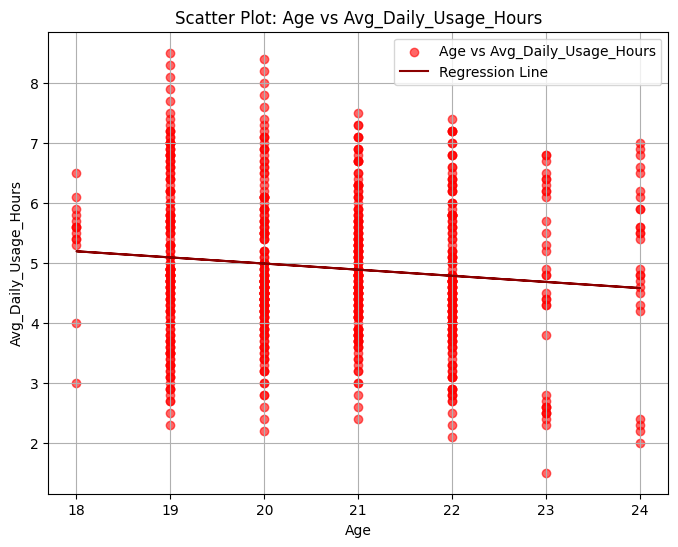


Pearson Correlation (r) between Age and Avg_Daily_Usage_Hours: -0.1137
Spearman Correlation (ρ) between Age and Avg_Daily_Usage_Hours: -0.1022

Correlation Matrix:
                            Age  Avg_Daily_Usage_Hours
Age                    1.000000              -0.113682
Avg_Daily_Usage_Hours -0.113682               1.000000



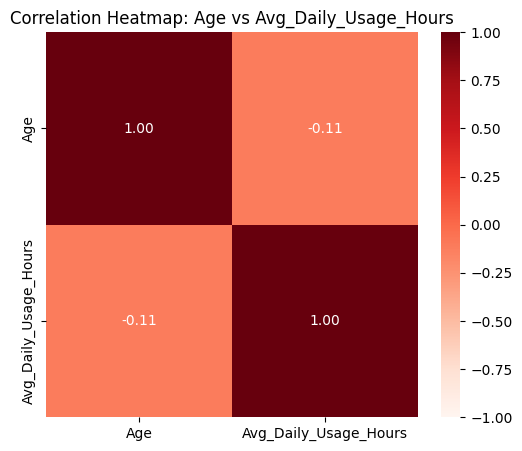

In [15]:
numerical_vs_numerical_analysis(df, 'Age', 'Avg_Daily_Usage_Hours', regression=True)

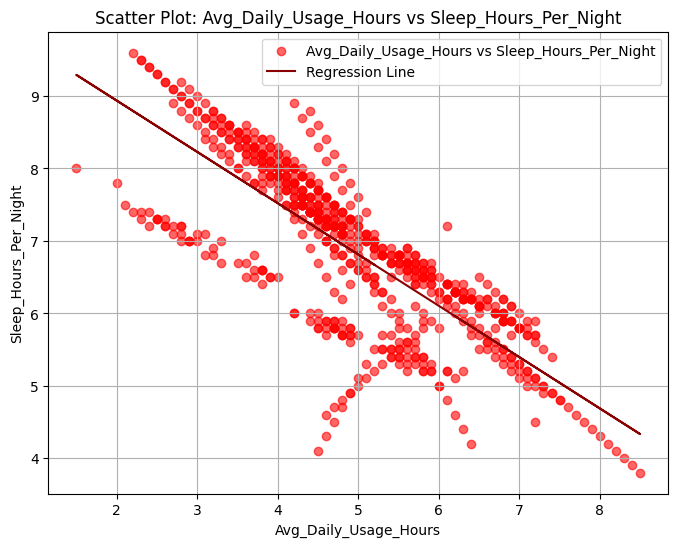


Pearson Correlation (r) between Avg_Daily_Usage_Hours and Sleep_Hours_Per_Night: -0.7906
Spearman Correlation (ρ) between Avg_Daily_Usage_Hours and Sleep_Hours_Per_Night: -0.8145

Correlation Matrix:
                       Avg_Daily_Usage_Hours  Sleep_Hours_Per_Night
Avg_Daily_Usage_Hours               1.000000              -0.790582
Sleep_Hours_Per_Night              -0.790582               1.000000



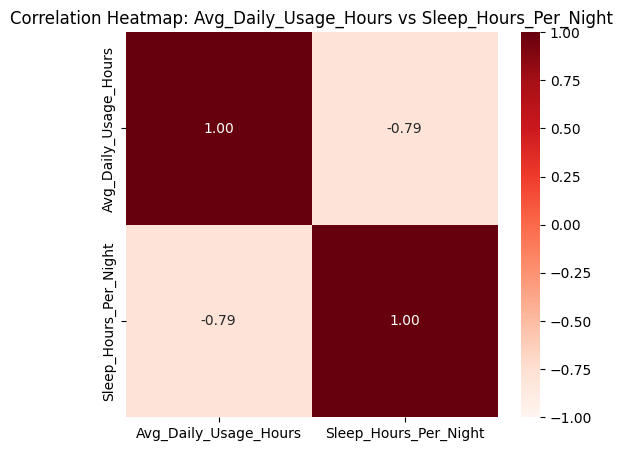

In [16]:
numerical_vs_numerical_analysis(df, 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', regression=True)

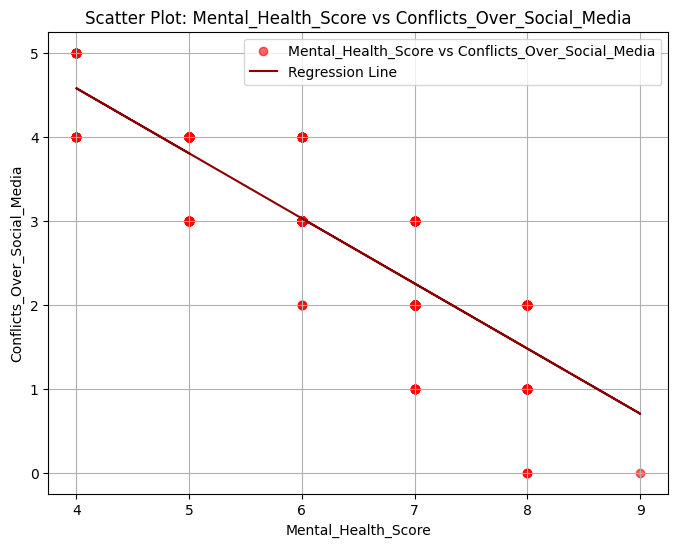


Pearson Correlation (r) between Mental_Health_Score and Conflicts_Over_Social_Media: -0.8936
Spearman Correlation (ρ) between Mental_Health_Score and Conflicts_Over_Social_Media: -0.9084

Correlation Matrix:
                             Mental_Health_Score  Conflicts_Over_Social_Media
Mental_Health_Score                     1.000000                    -0.893572
Conflicts_Over_Social_Media            -0.893572                     1.000000



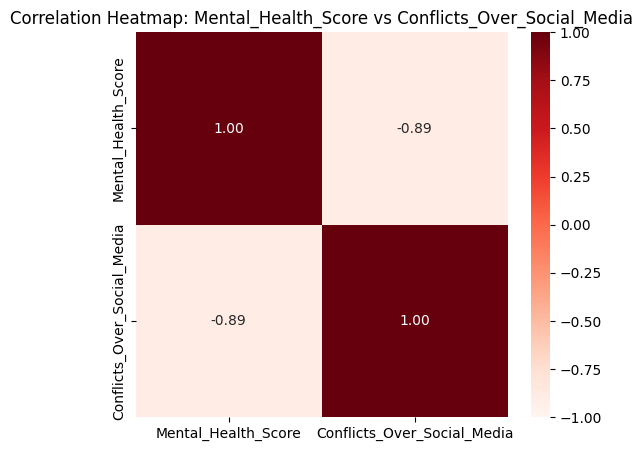

In [17]:
numerical_vs_numerical_analysis(df, 'Mental_Health_Score', 'Conflicts_Over_Social_Media', regression=True)

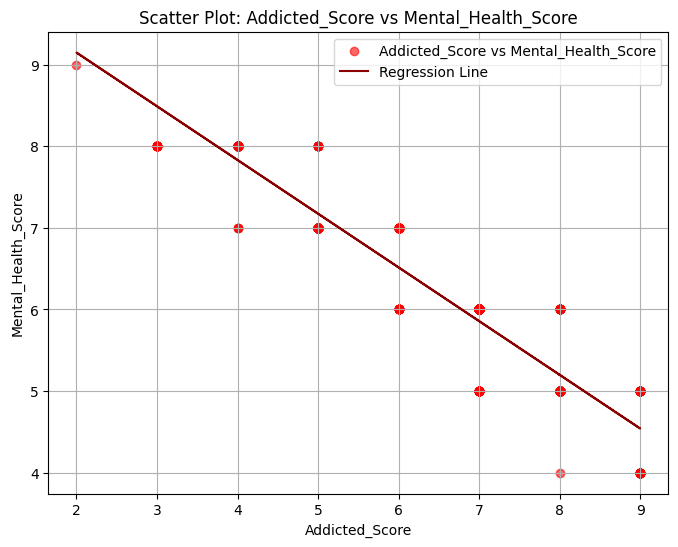


Pearson Correlation (r) between Addicted_Score and Mental_Health_Score: -0.9451
Spearman Correlation (ρ) between Addicted_Score and Mental_Health_Score: -0.9497

Correlation Matrix:
                     Addicted_Score  Mental_Health_Score
Addicted_Score             1.000000            -0.945051
Mental_Health_Score       -0.945051             1.000000



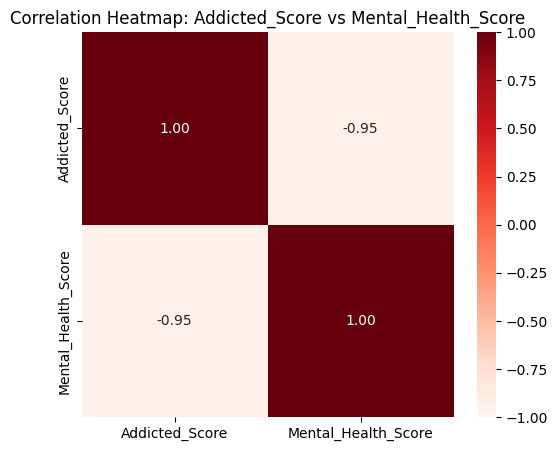

In [18]:
numerical_vs_numerical_analysis(df, 'Addicted_Score', 'Mental_Health_Score', regression=True)

## Numerical vs Categorical
- Age vs Academic_Level
- Avg_Daily_Usage_Hours vs Affects_Academic_Performance
- Sleep_Hours_Per_Night vs Relationship_Status

In [19]:
def numerical_vs_categorical_analysis(
    df: pd.DataFrame,
    num_var: str,
    cat_var: str,
    show_points: bool = True,
    violin: bool = False,
):
    """
    Bivariate analysis for a numerical vs categorical pair (no file saving).
    - Cleans NaNs on the fly
    - Orders categories by the group's median of the numerical variable
    - Red color theme
    - Welch t-test (2 groups) with Hedges' g
    - One-way ANOVA (>2 groups) with eta-squared (η²). Also prints Kruskal-Wallis as a nonparametric check.

    Parameters
    ----------
    df : DataFrame
    num_var : str
        Numerical column name
    cat_var : str
        Categorical column name
    show_points : bool, default True
        Overlay jittered points for distribution insight
    violin : bool, default False
        Use violin+box instead of plain box

    Returns
    -------
    dict with basic stats and test results
    """
    if num_var not in df.columns or cat_var not in df.columns:
        raise ValueError(f"Both '{num_var}' and '{cat_var}' must be columns in the dataframe.")
    if not np.issubdtype(df[num_var].dropna().dtype, np.number):
        raise TypeError(f"'{num_var}' must be numeric.")

    # --- Clean subset (drop rows with NA in either col) ---
    d = df[[num_var, cat_var]].dropna().copy()
    if d.empty:
        raise ValueError("No data left after dropping NaNs in the selected columns.")

    # Ensure categorical dtype (helps ordering & plotting)
    d[cat_var] = d[cat_var].astype("category")

    # Order categories by median of the numerical variable (more readable)
    order = (
        d.groupby(cat_var)[num_var]
        .median()
        .sort_values()
        .index
        .tolist()
    )
    d[cat_var] = d[cat_var].cat.reorder_categories(order, ordered=True)

    # --- Plot: red theme ---
    plt.figure(figsize=(9, 6))
    if violin:
        sns.violinplot(
            data=d,
            x=cat_var,
            y=num_var,
            order=order,
            inner=None,
            palette=sns.color_palette("Reds", len(order))
        )
        sns.boxplot(
            data=d,
            x=cat_var,
            y=num_var,
            order=order,
            showcaps=True,
            boxprops={"facecolor":"none", "edgecolor":"darkred"},
            whiskerprops={"color":"darkred"},
            medianprops={"color":"darkred"},
            showfliers=False
        )
    else:
        sns.boxplot(
            data=d,
            x=cat_var,
            y=num_var,
            order=order,
            palette=sns.color_palette("Reds", len(order)),
            showfliers=False
        )

    if show_points:
        sns.stripplot(
            data=d,
            x=cat_var,
            y=num_var,
            order=order,
            alpha=0.35,
            jitter=0.25,
            color="darkred"
        )

    plt.title(f"{num_var} across {cat_var}")
    plt.xlabel(cat_var)
    plt.ylabel(num_var)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

    # --- Stats ---
    # Category counts (useful sanity check)
    counts = d[cat_var].value_counts().reindex(order)

    # Prepare groups
    groups = [g[1][num_var].values for g in d.groupby(cat_var)]
    k = len(groups)

    results = {
        "counts": counts.to_dict(),
        "k_groups": k,
        "group_order": order,
        "tests": {}
    }

    # Two groups -> Welch t-test + Hedges' g
    if k == 2:
        g1, g2 = groups
        t_stat, p_val = stats.ttest_ind(g1, g2, equal_var=False, nan_policy="omit")

        # Hedges' g (bias-corrected Cohen's d)
        n1, n2 = len(g1), len(g2)
        s1, s2 = np.var(g1, ddof=1), np.var(g2, ddof=1)
        sp = np.sqrt(((n1-1)*s1 + (n2-1)*s2) / (n1 + n2 - 2)) if (n1 + n2 - 2) > 0 else np.nan
        d_val = (np.mean(g1) - np.mean(g2)) / sp if sp > 0 else np.nan
        J = 1 - (3 / (4*(n1 + n2) - 9)) if (n1 + n2) > 2 else 1.0
        hedges_g = J * d_val if np.isfinite(d_val) else np.nan

        print(f"\nT-test (Welch): t = {t_stat:.4f}, p = {p_val:.4f} | Hedges' g = {hedges_g:.3f}")
        results["tests"]["welch_t"] = {"t": float(t_stat), "p": float(p_val), "hedges_g": float(hedges_g)}

    # More than two groups -> ANOVA + η²; also Kruskal as robustness check
    else:
        # ANOVA (one-way, classical)
        f_stat, p_val = stats.f_oneway(*groups)
        # eta-squared
        all_vals = d[num_var].values
        grand_mean = np.mean(all_vals)
        ss_between = sum(len(g)*((np.mean(g) - grand_mean)**2) for g in groups)
        ss_total = np.sum((all_vals - grand_mean)**2)
        eta_sq = ss_between / ss_total if ss_total > 0 else np.nan

        print(f"\nANOVA: F = {f_stat:.4f}, p = {p_val:.4f} | eta² = {eta_sq:.3f}")
        results["tests"]["anova"] = {"F": float(f_stat), "p": float(p_val), "eta2": float(eta_sq)}

        # Kruskal-Wallis (nonparametric alternative)
        kw_stat, kw_p = stats.kruskal(*groups)
        print(f"Kruskal-Wallis: H = {kw_stat:.4f}, p = {kw_p:.4f}")
        results["tests"]["kruskal"] = {"H": float(kw_stat), "p": float(kw_p)}

    return results

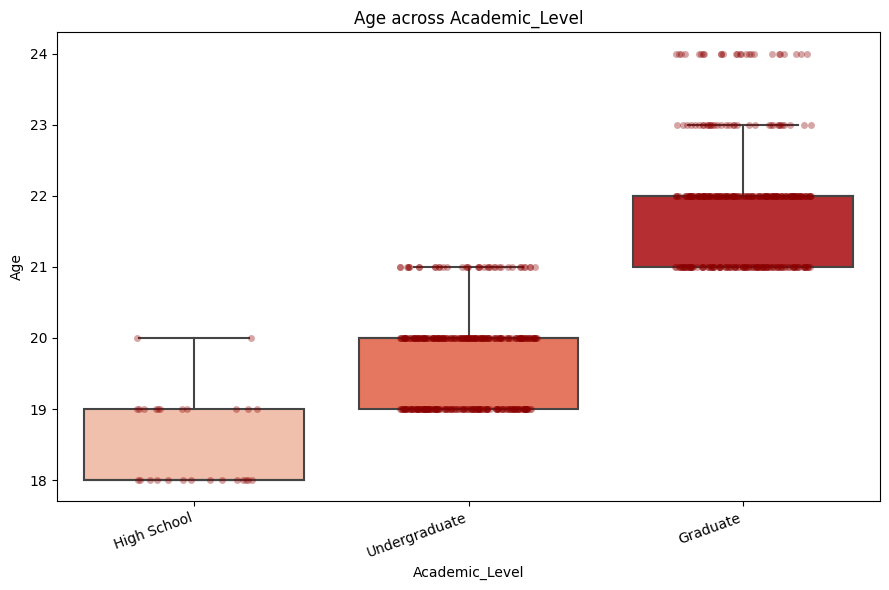


ANOVA: F = 809.9852, p = 0.0000 | eta² = 0.698
Kruskal-Wallis: H = 523.6756, p = 0.0000


{'counts': {'High School': 27, 'Undergraduate': 353, 'Graduate': 325},
 'k_groups': 3,
 'group_order': ['High School', 'Undergraduate', 'Graduate'],
 'tests': {'anova': {'F': 809.9851557456685,
   'p': 4.4528471696116395e-183,
   'eta2': 0.6976705530962946},
  'kruskal': {'H': 523.6756023920487, 'p': 1.9288026181780674e-114}}}

In [20]:
numerical_vs_categorical_analysis(df, 'Age', 'Academic_Level')

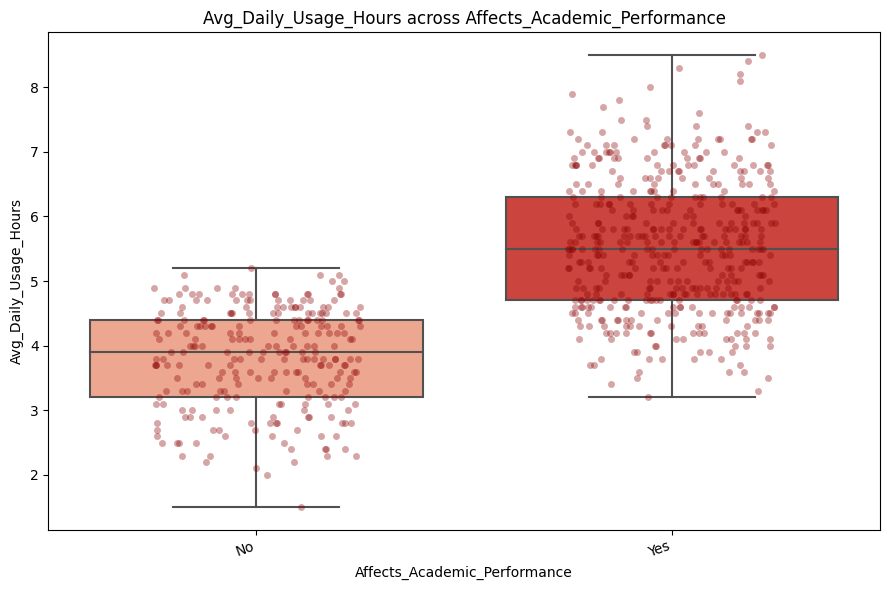


T-test (Welch): t = -25.3941, p = 0.0000 | Hedges' g = -1.836


{'counts': {'No': 252, 'Yes': 453},
 'k_groups': 2,
 'group_order': ['No', 'Yes'],
 'tests': {'welch_t': {'t': -25.3940647304039,
   'p': 3.2315190788252453e-99,
   'hedges_g': -1.8358151548348287}}}

In [21]:
numerical_vs_categorical_analysis(df, 'Avg_Daily_Usage_Hours', 'Affects_Academic_Performance')

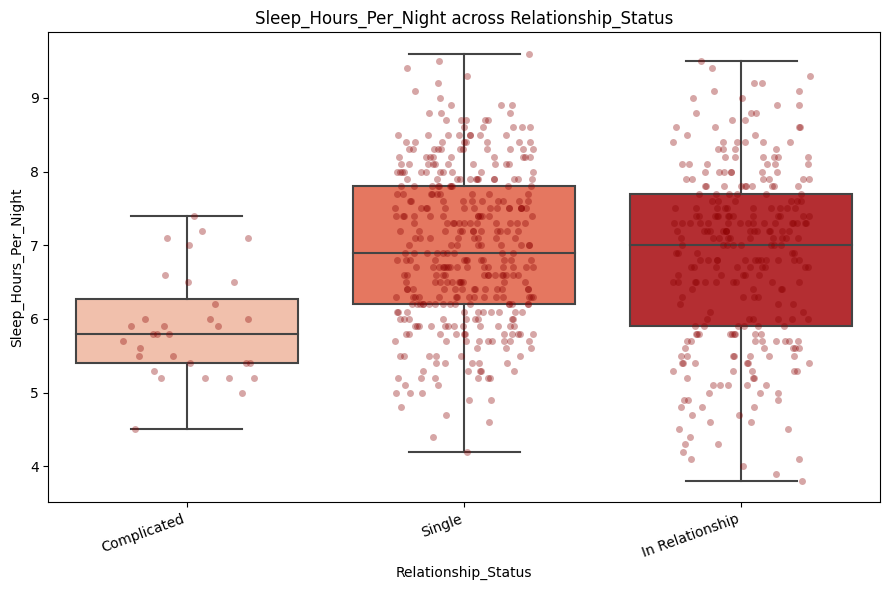


ANOVA: F = 14.3548, p = 0.0000 | eta² = 0.039
Kruskal-Wallis: H = 29.3494, p = 0.0000


{'counts': {'Complicated': 32, 'Single': 384, 'In Relationship': 289},
 'k_groups': 3,
 'group_order': ['Complicated', 'Single', 'In Relationship'],
 'tests': {'anova': {'F': 14.354775486341742,
   'p': 7.760812393233985e-07,
   'eta2': 0.03928996265953647},
  'kruskal': {'H': 29.349395458922512, 'p': 4.235061803470506e-07}}}

In [22]:
numerical_vs_categorical_analysis(df, 'Sleep_Hours_Per_Night', 'Relationship_Status')

## Categorical vs Categorical
- Gender vs Academic_Level
- Most_Used_Platform vs Affects_Academic_Performance
- Country vs Affects_Academic_Performance
- Mental_Health_Score vs Relationship_Status

In [23]:
def _cramers_v_bias_corrected(chi2, n, r, c):
    """Bias-corrected Cramér's V (Bergsma 2013)."""
    phi2 = chi2 / n
    phi2_corr = max(0, phi2 - ((r-1)*(c-1))/(n-1))
    r_corr = r - ((r-1)**2)/(n-1)
    c_corr = c - ((c-1)**2)/(n-1)
    denom = min(r_corr-1, c_corr-1)
    return np.sqrt(phi2_corr / denom) if denom > 0 else 0.0

def categorical_vs_categorical_analysis(
    df: pd.DataFrame,
    cat_var1: str,
    cat_var2: str,
    top_n: int | None = None,
    normalize: str | None = "row",   # None | "row" | "column"
    dropna: bool = True,
):
    """
    Bivariate analysis for two categorical variables (no saving).
    - Cleans NaNs (optional), optional top-N levels of cat_var1
    - Red-themed stacked bar (counts or percentages)
    - Chi-square test + expected table
    - Bias-corrected Cramér’s V

    Returns
    -------
    dict with chi2 test, Cramér’s V, contingency, expected
    """
    # --- Validation ---
    if cat_var1 not in df.columns or cat_var2 not in df.columns:
        raise ValueError(f"Both '{cat_var1}' and '{cat_var2}' must be columns in the dataframe.")

    d = df[[cat_var1, cat_var2]].copy()
    if dropna:
        d = d.dropna(subset=[cat_var1, cat_var2])
    else:
        d[cat_var1] = d[cat_var1].astype(str).fillna("Missing")
        d[cat_var2] = d[cat_var2].astype(str).fillna("Missing")

    # Optional top-N by cat_var1 frequency
    if top_n is not None and top_n > 0:
        keep = d[cat_var1].value_counts().nlargest(top_n).index
        d = d[d[cat_var1].isin(keep)]

    # Contingency (no margins for stats)
    contingency = pd.crosstab(d[cat_var1], d[cat_var2])
    if contingency.empty or (contingency.values.sum() == 0):
        raise ValueError("Contingency table is empty after filtering—nothing to analyze.")

    # Chi-square & expected
    chi2, p, dof, expected = chi2_contingency(contingency.values, correction=False)
    n = contingency.values.sum()
    r, c = contingency.shape
    cramers_v = _cramers_v_bias_corrected(chi2, n, r, c)

    print("\nContingency Table (counts):")
    print(contingency)
    print("\nExpected Counts (under independence):")
    print(pd.DataFrame(expected, index=contingency.index, columns=contingency.columns))
    print(f"\nChi-square: χ² = {chi2:.4f}, dof = {dof}, p = {p:.6f}")
    print(f"Cramér’s V (bias-corrected): {cramers_v:.4f}\n")

    # --- Plot: stacked bars (counts or %), red palette ---
    plot_data = contingency.copy()
    title_suffix = "Counts"
    if normalize == "row":
        plot_data = plot_data.div(plot_data.sum(axis=1), axis=0) * 100
        title_suffix = "Row %"
    elif normalize == "column":
        plot_data = plot_data.div(plot_data.sum(axis=0), axis=1) * 100
        title_suffix = "Column %"

    # Ensure consistent red palette by number of stacks (cat_var2 levels)
    palette = sns.color_palette("Reds", n_colors=plot_data.shape[1])

    ax = plot_data.plot(
        kind="bar",
        stacked=True,
        figsize=(12, 6),
        color=palette,
        edgecolor="black",
        linewidth=0.6
    )
    ax.set_title(f"{cat_var1} vs {cat_var2} — {title_suffix}")
    ax.set_xlabel(cat_var1)
    ax.set_ylabel("Percentage" if title_suffix.endswith("%") else "Count")
    plt.xticks(rotation=20, ha="right")
    plt.legend(title=cat_var2, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    plt.tight_layout()
    plt.show()

    return {
        "chi2": float(chi2),
        "p_value": float(p),
        "dof": int(dof),
        "cramers_v": float(cramers_v),
        "contingency": contingency,
        "expected": pd.DataFrame(expected, index=contingency.index, columns=contingency.columns),
    }


Contingency Table (counts):
Academic_Level  Graduate  High School  Undergraduate
Gender                                              
Female                48           15            290
Male                 277           12             63

Expected Counts (under independence):
Academic_Level    Graduate  High School  Undergraduate
Gender                                                
Female          162.730496    13.519149     176.750355
Male            162.269504    13.480851     176.249645

Chi-square: χ² = 307.6640, dof = 2, p = 0.000000
Cramér’s V (bias-corrected): 0.6589



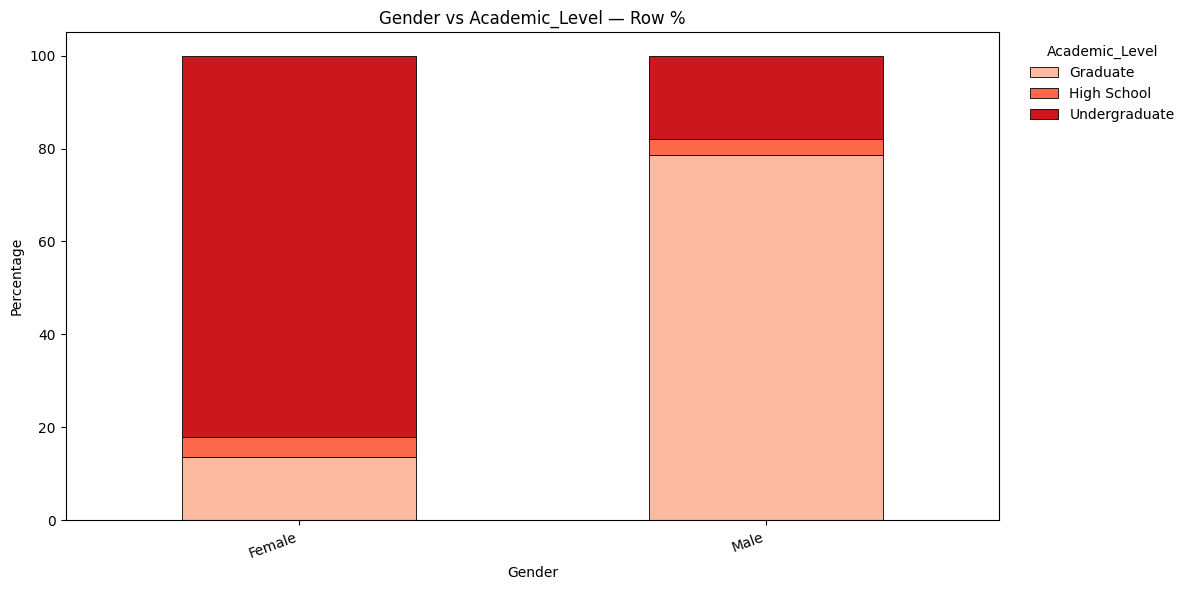

{'chi2': 307.66396123087003,
 'p_value': 1.5546036336517837e-67,
 'dof': 2,
 'cramers_v': 0.6589223048039209,
 'contingency': Academic_Level  Graduate  High School  Undergraduate
 Gender                                              
 Female                48           15            290
 Male                 277           12             63,
 'expected': Academic_Level    Graduate  High School  Undergraduate
 Gender                                                
 Female          162.730496    13.519149     176.750355
 Male            162.269504    13.480851     176.249645}

In [24]:
categorical_vs_categorical_analysis(df, 'Gender', 'Academic_Level')


Contingency Table (counts):
Affects_Academic_Performance  No  Yes
Most_Used_Platform                   
Facebook                      86   37
Instagram                     77  172
KakaoTalk                      0   12
LINE                          12    0
LinkedIn                      21    0
Snapchat                       1   12
TikTok                        10  144
Twitter                       19   11
VKontakte                     12    0
WeChat                         7    8
WhatsApp                       0   54
YouTube                        7    3

Expected Counts (under independence):
Affects_Academic_Performance         No         Yes
Most_Used_Platform                                 
Facebook                      43.965957   79.034043
Instagram                     89.004255  159.995745
KakaoTalk                      4.289362    7.710638
LINE                           4.289362    7.710638
LinkedIn                       7.506383   13.493617
Snapchat                       4.646

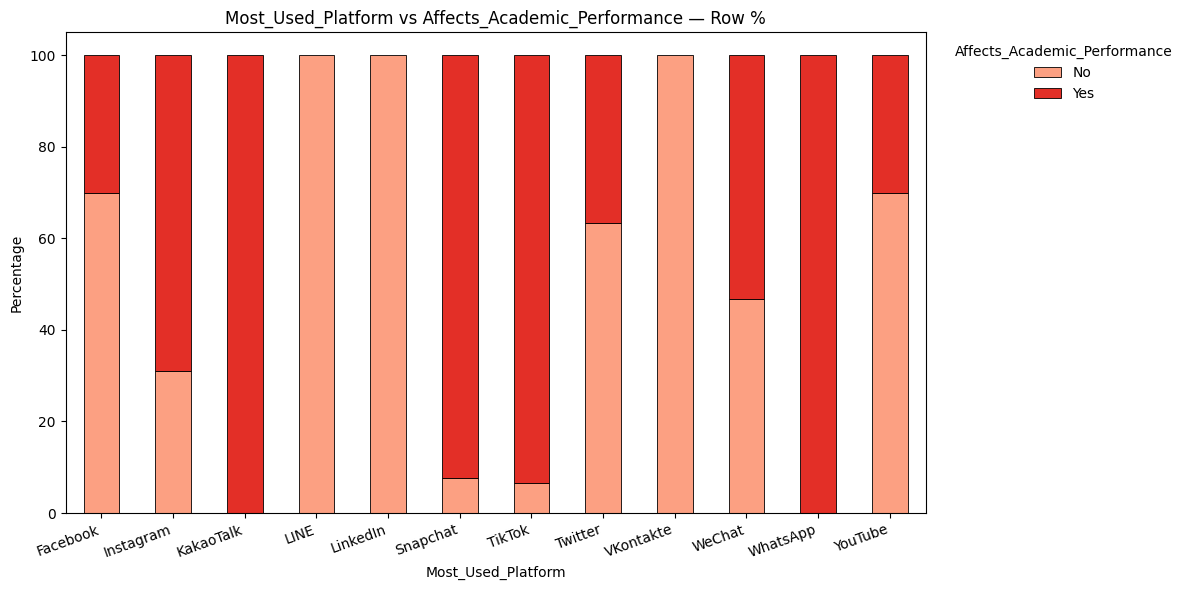

{'chi2': 260.32467757702057,
 'p_value': 1.9173448996421894e-49,
 'dof': 11,
 'cramers_v': 0.5950906582082969,
 'contingency': Affects_Academic_Performance  No  Yes
 Most_Used_Platform                   
 Facebook                      86   37
 Instagram                     77  172
 KakaoTalk                      0   12
 LINE                          12    0
 LinkedIn                      21    0
 Snapchat                       1   12
 TikTok                        10  144
 Twitter                       19   11
 VKontakte                     12    0
 WeChat                         7    8
 WhatsApp                       0   54
 YouTube                        7    3,
 'expected': Affects_Academic_Performance         No         Yes
 Most_Used_Platform                                 
 Facebook                      43.965957   79.034043
 Instagram                     89.004255  159.995745
 KakaoTalk                      4.289362    7.710638
 LINE                           4.289362    7.7106

In [25]:
categorical_vs_categorical_analysis(df, 'Most_Used_Platform', 'Affects_Academic_Performance')


Contingency Table (counts):
Affects_Academic_Performance  No  Yes
Country                              
Bangladesh                     0   20
Canada                         1   33
Denmark                       27    0
France                        25    2
India                         11   42
Ireland                        0   27
Italy                          9   12
Japan                         21    0
Maldives                       8   11
Mexico                         0   27
Nepal                          9   10
Pakistan                       0   19
Poland                         8    8
Russia                        13    8
Spain                          0   27
Sri Lanka                     11    8
Switzerland                   27    0
Turkey                         0   27
UK                             1   21
USA                            0   40

Expected Counts (under independence):
Affects_Academic_Performance         No        Yes
Country                                      

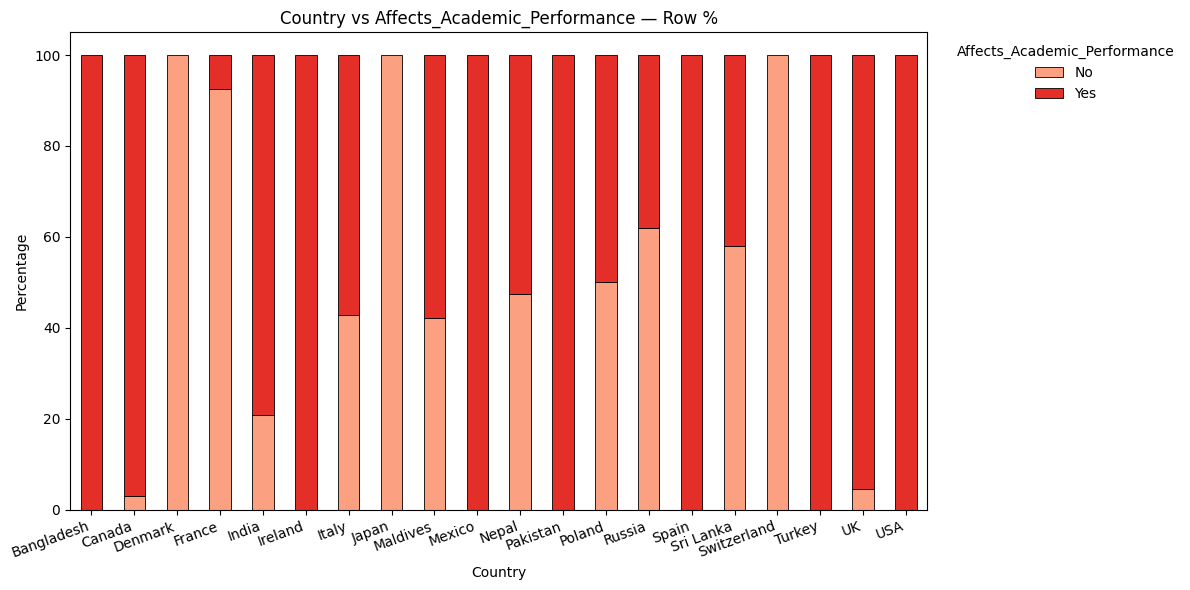

{'chi2': 330.34857853947756,
 'p_value': 1.1598764989516116e-58,
 'dof': 19,
 'cramers_v': 0.7797644084413639,
 'contingency': Affects_Academic_Performance  No  Yes
 Country                              
 Bangladesh                     0   20
 Canada                         1   33
 Denmark                       27    0
 France                        25    2
 India                         11   42
 Ireland                        0   27
 Italy                          9   12
 Japan                         21    0
 Maldives                       8   11
 Mexico                         0   27
 Nepal                          9   10
 Pakistan                       0   19
 Poland                         8    8
 Russia                        13    8
 Spain                          0   27
 Sri Lanka                     11    8
 Switzerland                   27    0
 Turkey                         0   27
 UK                             1   21
 USA                            0   40,
 'expected': Af

In [26]:
categorical_vs_categorical_analysis(df, 'Country', 'Affects_Academic_Performance', top_n=20)


Contingency Table (counts):
Relationship_Status  Complicated  In Relationship  Single
Mental_Health_Score                                      
4                              1                6      22
5                             12               82      79
6                             11               61     147
7                              4              100      74
8                              4               40      61
9                              0                0       1

Expected Counts (under independence):
Relationship_Status  Complicated  In Relationship      Single
Mental_Health_Score                                          
4                       1.316312        11.887943   15.795745
5                       7.852482        70.917730   94.229787
6                       9.940426        89.774468  119.285106
7                       8.079433        72.967376   96.953191
8                       4.765957        43.042553   57.191489
9                       0.045390  

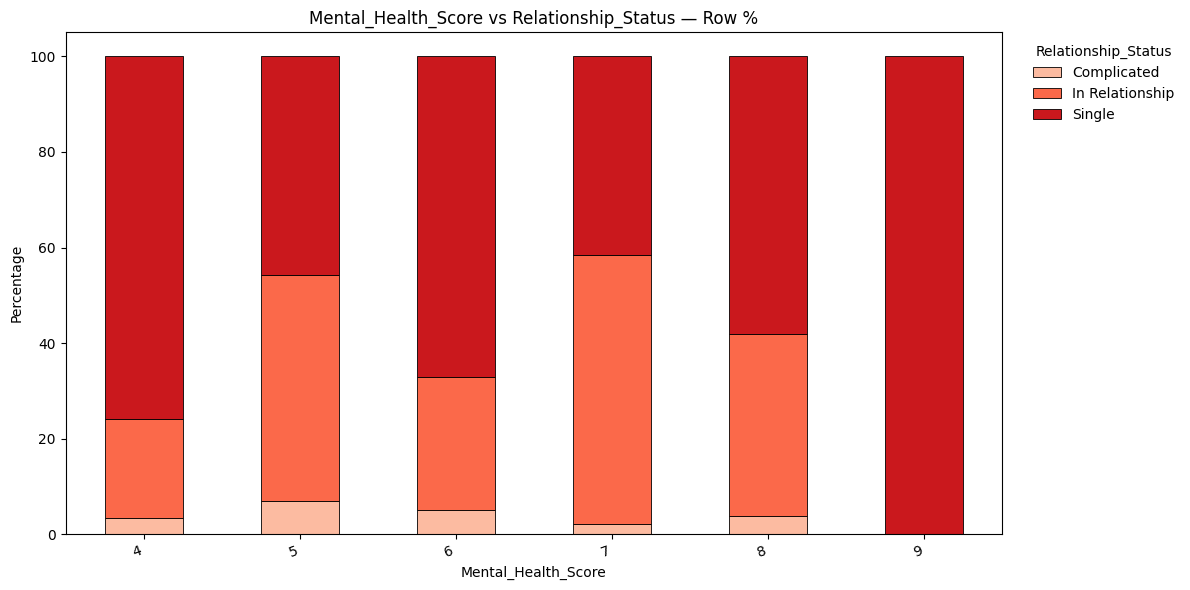

{'chi2': 46.52460792917698,
 'p_value': 1.152080365418284e-06,
 'dof': 10,
 'cramers_v': 0.16114488795103746,
 'contingency': Relationship_Status  Complicated  In Relationship  Single
 Mental_Health_Score                                      
 4                              1                6      22
 5                             12               82      79
 6                             11               61     147
 7                              4              100      74
 8                              4               40      61
 9                              0                0       1,
 'expected': Relationship_Status  Complicated  In Relationship      Single
 Mental_Health_Score                                          
 4                       1.316312        11.887943   15.795745
 5                       7.852482        70.917730   94.229787
 6                       9.940426        89.774468  119.285106
 7                       8.079433        72.967376   96.953191
 8          

In [27]:
categorical_vs_categorical_analysis(df, 'Mental_Health_Score', 'Relationship_Status')

# Feature Engineering

In [28]:
# Feature Engineering

In [29]:
df.drop("Student_ID", axis=1, inplace=True)

In [30]:
# Encode all categorical columns automatically

object_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in object_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score
0,19,0,2,10,5.2,1,1,6.5,6,1,3,8
1,22,1,0,39,2.1,7,0,7.5,8,2,0,3
2,20,0,2,102,6.0,6,1,5.0,5,0,4,9
3,18,1,1,101,3.0,11,0,7.0,7,2,1,4
4,21,1,0,18,4.5,0,1,6.0,6,1,2,7


# Modeling

## Addicted score (Classification)

In [31]:
# Create binary classification target
df["Target"] = df["Addicted_Score"].apply(lambda x: 1 if x >= 7 else 0)

In [32]:
# Define features and target
X = df.drop(["Addicted_Score", "Target"], axis=1)
y = df["Target"]

In [33]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=537, stratify=y
)

In [35]:
# Train logistic regression model
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [36]:
# Make predictions using each model
y_pred_lr = lr.predict(X_test)

Accuracy: 0.9774
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        75
           1       0.97      0.99      0.98       102

    accuracy                           0.98       177
   macro avg       0.98      0.98      0.98       177
weighted avg       0.98      0.98      0.98       177



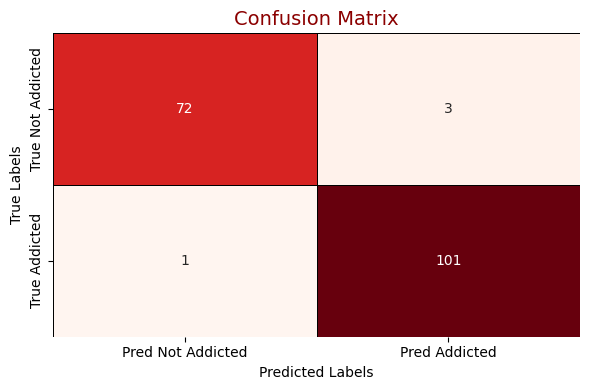

In [37]:
def evaluate_model(model, X_test, y_test, class_names=None):
    """
    Evaluate a classification model with accuracy, classification report, and confusion matrix (red theme).
    
    Parameters
    ----------
    model : sklearn-like estimator (must have predict method)
    X_test : array-like, test features
    y_test : array-like, true labels
    class_names : list of str, optional
        Names of classes for display. If None, inferred from y_test unique values.

    Returns
    -------
    dict with accuracy, report, confusion_matrix
    """
    # Predictions
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Print summary
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    # Labels
    if class_names is None:
        labels = [str(cls) for cls in sorted(set(y_test))]
    else:
        labels = class_names

    # Plot confusion matrix (red theme)
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Reds",   # red palette
        xticklabels=[f"Pred {l}" for l in labels],
        yticklabels=[f"True {l}" for l in labels],
        cbar=False,
        linewidths=0.5,
        linecolor="black"
    )
    plt.title("Confusion Matrix", fontsize=14, color="darkred")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "report": report,
        "confusion_matrix": conf_matrix
    }

results = evaluate_model(lr, X_test, y_test, class_names=["Not Addicted", "Addicted"])

## Mental health score 

In [38]:
# Define features and target
X = df.drop(columns=["Mental_Health_Score", "Target"])
y = df["Mental_Health_Score"]

In [39]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.25, random_state=537)

In [41]:
# XGBoost model
xgboost_model = xgb.XGBRegressor(random_state=42)
xgboost_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [42]:
# Gradient Boosting model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [43]:
# Random Forest model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [44]:
# Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [45]:
# Make predictions using each model
y_pred_xgboost = xgboost_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)
y_pred_gb = gb_model.predict(X_test)
y_pred_lr = lr_model.predict(X_test)

# Evaluate XGBoost model
mse_xgboost = mean_squared_error(y_test, y_pred_xgboost)
r2_xgboost = r2_score(y_test, y_pred_xgboost)

# Evaluate Random Forest model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Evaluate Gradient Boosting model
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

# Evaluate Linear Regression model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

In [46]:
# Print evaluation metrics
print(f"\nXGBoost - Mean Squared Error: {mse_xgboost:.4f}, R² Score: {r2_xgboost:.4f}")
print(f"Random Forest - Mean Squared Error: {mse_rf:.4f}, R² Score: {r2_rf:.4f}")
print(f"Gradient Boosting - Mean Squared Error: {mse_gb:.4f}, R² Score: {r2_gb:.4f}")
print(f"Linear Regression - Mean Squared Error: {mse_lr:.4f}, R² Score: {r2_lr:.4f}\n")


XGBoost - Mean Squared Error: 0.0668, R² Score: 0.9504
Random Forest - Mean Squared Error: 0.0608, R² Score: 0.9548
Gradient Boosting - Mean Squared Error: 0.0584, R² Score: 0.9566
Linear Regression - Mean Squared Error: 0.1583, R² Score: 0.8824



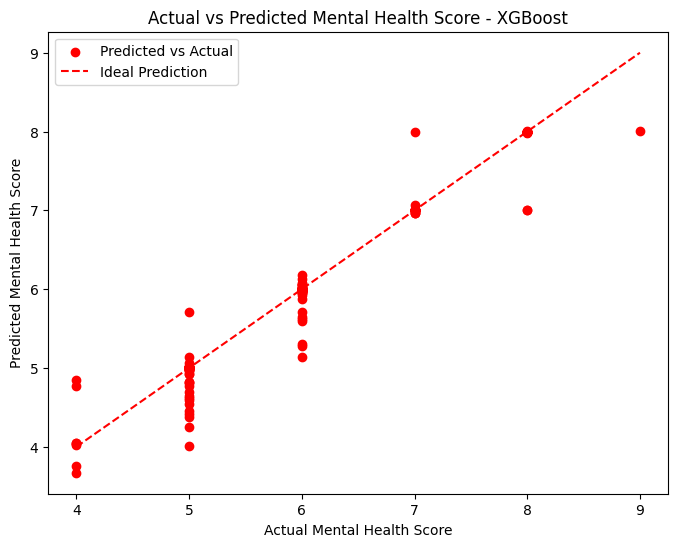

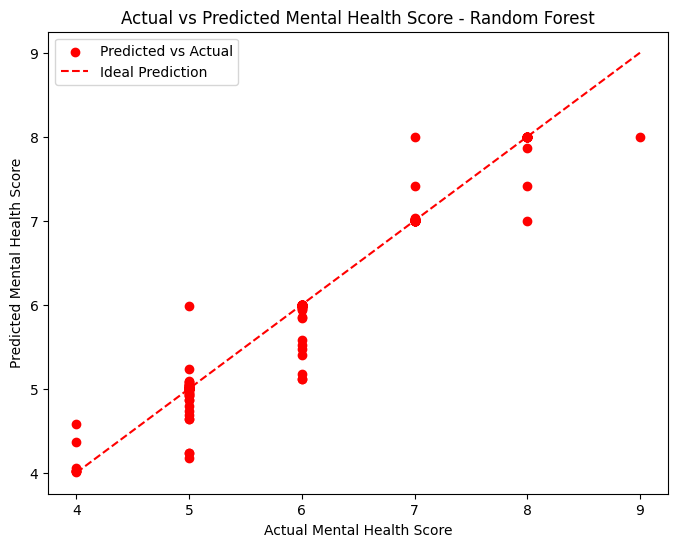

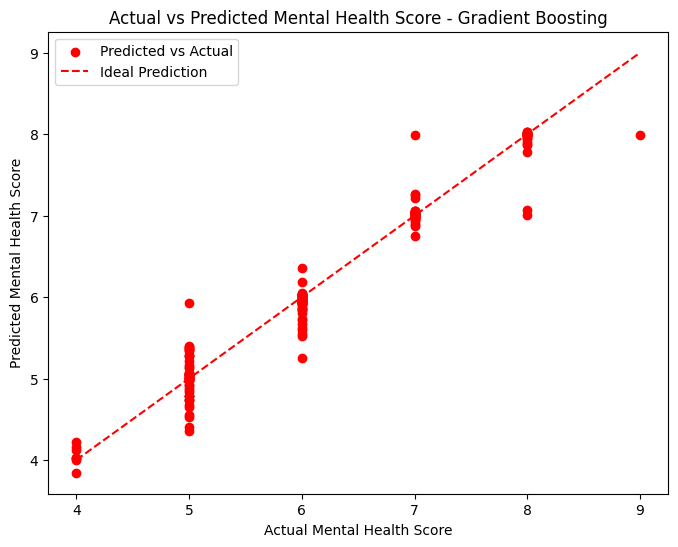

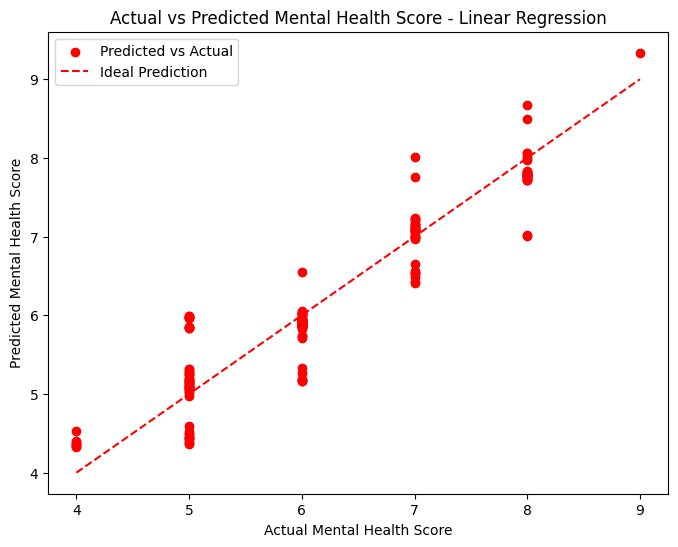

In [47]:
# Plot Actual vs Predicted for each model
def plot_actual_vs_predicted(y_test, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, color='red', label='Predicted vs Actual')
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label="Ideal Prediction")
    plt.xlabel("Actual Mental Health Score")
    plt.ylabel("Predicted Mental Health Score")
    plt.title(f"Actual vs Predicted Mental Health Score - {model_name}")
    plt.legend()
    plt.show()

plot_actual_vs_predicted(y_test, y_pred_xgboost, "XGBoost")
plot_actual_vs_predicted(y_test, y_pred_rf, "Random Forest")
plot_actual_vs_predicted(y_test, y_pred_gb, "Gradient Boosting")
plot_actual_vs_predicted(y_test, y_pred_lr, "Linear Regression")

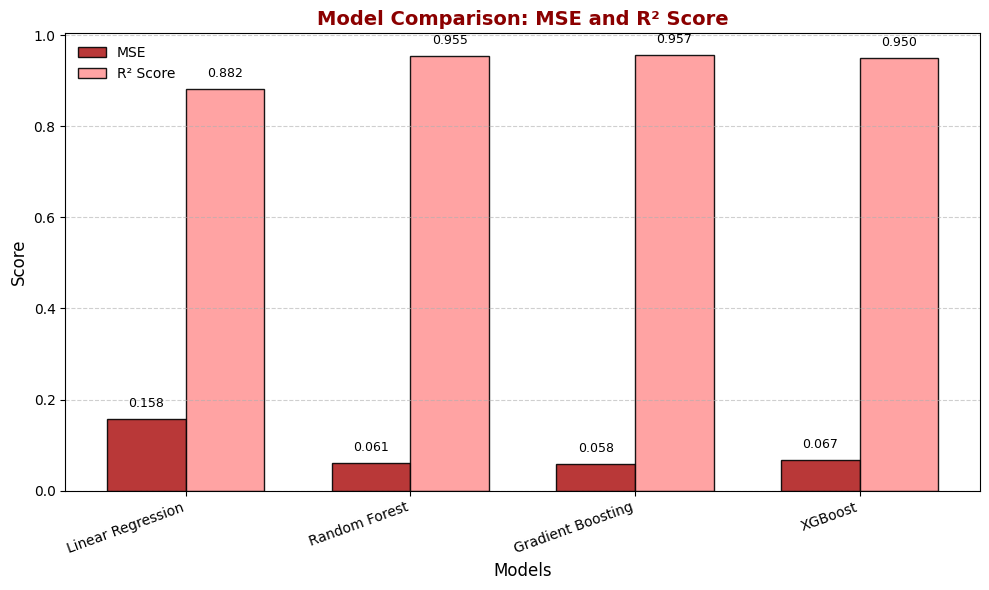

In [48]:
mse_values = [mse_lr, mse_rf, mse_gb, mse_xgboost]
r2_values = [r2_lr, r2_rf, r2_gb, r2_xgboost]
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, mse_values, width, label='MSE', 
               color='#b22222', edgecolor='black', alpha=0.9) 
bars2 = ax.bar(x + width/2, r2_values, width, label='R² Score', 
               color='#ff9999', edgecolor='black', alpha=0.9)  

ax.set_title('Model Comparison: MSE and R² Score', fontsize=14, color='darkred', weight='bold')
ax.set_xlabel('Models', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha='right')
ax.legend(frameon=False)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)

def add_values(bars, fmt="{:.3f}"):
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                yval + (0.02 * max(max(mse_values), max(r2_values))),
                fmt.format(yval),
                ha='center', va='bottom', fontsize=9, color='black', rotation=0)

add_values(bars1)
add_values(bars2)
plt.tight_layout()
plt.show()